In [1]:
# from jax.lib import xla_bridge
# import jax
# print(xla_bridge.get_backend().platform)
# # name = "cuDNN"
# jax._src.lib.cuda_versions.cudnn_get_version()
# # jax._src.lib.cuda_versions.cudnn_build_version()
# jax.default_device = jax.devices("gpu")[0]

# # # bp.math.set_platform("cpu")
# import os
# # if bp.math.get_platform() == 'cpu':
# threads = os.cpu_count()//10
# os.environ["XLA_FLAGS"] = '--xla_force_host_platform_device_count=' + str(threads)
# print(os.environ["XLA_FLAGS"])

In [2]:
import brainpy as bp
import numpy as np
import matplotlib.pyplot as plt
import networkx as nx
import jax
import jax.numpy as jnp
import sys
import os

src_dir = os.path.abspath(os.path.join('../../../'))
sys.path.insert(0, src_dir)
import src
# plt.style.use('../../../foresight.mplstyle')


/headnode2/bhar9988/code/DDC/WRCircuit.jl/.CondaPkg/env/lib/python3.11/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [3]:
# bp.math.set_dt(0.05) # Check sims look similar with smaller timestep

# Parameterizing by mass means the balance condition is independent of sigma
# zeta_e = (delta*omega_ie)/(gamma*omega_ee)
# zeta_i = (delta*omega_ii)/(gamma*omega_ei)

# * If delta == gamma (population size exactly balanced by synaptic weight), zeta balance
#   reduces to omega_ie == omega_ee and omega_ii == omega_ei


dx = 1.0 #0.75 # mm
rho = 15000.
kernel = src.distances.GaussianKernel
J_e = 0.0011 # Microsiemens
delta = 0.85 # 2.9
nu = 10. # Preserve; the minimum required for spontaneous spiking
n_ext = 45

sigma_ee = 0.075
sigma_ei = 0.1
sigma_ie = 0.2
sigma_ii = 0.2

omega_ee = 0.003
omega_ie = 0.020

omega_ei = 0.006 # The relative strength of these two components controls intensity/sparseness of pattern?
omega_ii = 0.032




print("p_ee: ", kernel.mass2pmax(omega_ee, sigma_ee))
print("p_ei: ", kernel.mass2pmax(omega_ei, sigma_ei))
print("p_ie: ", kernel.mass2pmax(omega_ie, sigma_ie))
print("p_ii: ", kernel.mass2pmax(omega_ii, sigma_ii))

p_ee:  0.08488263631567751
p_ei:  0.0954929658551372
p_ie:  0.07957747154594766
p_ii:  0.12732395447351627


In [4]:
from src.models.WRCircuit import WRCircuit

FNSnet = WRCircuit(rho = rho,
        dx=dx,
        J_e = J_e,
        nu = nu,
        n_ext = n_ext,
        delta=delta,
        omega_ee=omega_ee,
        omega_ei=omega_ei,
        omega_ie=omega_ie,
        omega_ii=omega_ii,
        sigma_ee=sigma_ee,
        sigma_ei=sigma_ei,
        sigma_ie=sigma_ie,
        sigma_ii=sigma_ii,
        kernel=kernel,
        key=jax.random.PRNGKey(42))
FNSnet.reinit_weights(delta, J_e)

/headnode2/bhar9988/code/DDC/WRCircuit.jl/.CondaPkg/env/lib/python3.11/site-packages/brainpy/_src/dyn/others/input.py:212: UserWarning: 
  warnings.warn('')


In [5]:
# FNSnet.get_input_params()
# model = FNSnet.update_copy(J_e=0.0)


In [6]:
# bp.odeint(FNSnet.E.dV, show_code=True)
# bp.odeint(bp.JointEq([FNSnet.E.dV, FNSnet.E.dg_K]), show_code=True)

In [7]:
print("Num. Exc.:");print(np.prod(FNSnet.E.size))
print("Num. Inh.:");print(np.prod(FNSnet.I.size))

Num. Exc.:
14884
Num. Inh.:
3721


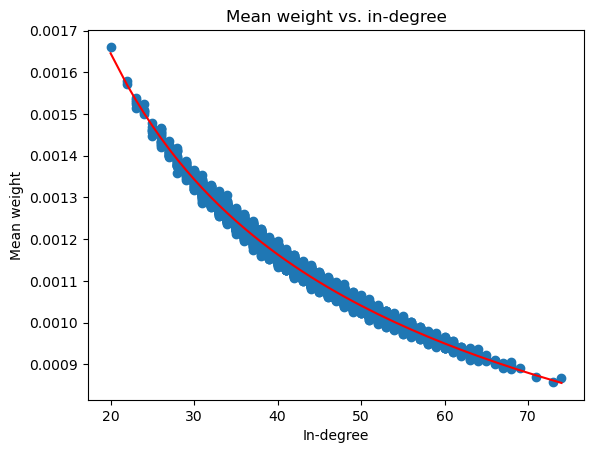

E2E in-degree: 44.5 (mean), 45.0 (gaussian expected)
E2I in-degree: 89.1 (mean), 90.0 (gaussian expected)
I2E in-degree: 72.6 (mean), 75.0 (gaussian expected)
I2I in-degree: 116.2 (mean), 120.0 (gaussian expected)
External in-degree (Exc.): 45.0 (mean)
External in-degree (Inh.): 44.8 (mean)


In [8]:
def mean_weights(proj):
    """
    Calculate the mean input weight for each postsynaptic neuron.
    That is, for each post-syn index i, we compute:
        mean_weights[i] = (sum of weights of all edges leading to i) / (number of edges leading to i).
    """
    # Number of post-synaptic neurons
    M = jnp.prod(jnp.array(proj.post.size))

    # 'indices' is a 1D array listing which post-syn neuron each edge connects to
    indices = jnp.array(proj.comm.indices)
    # 'weight' holds the corresponding weight for each edge in the same order
    weights = jnp.array(proj.comm.weight)

    # 1) in-degree count: how many edges lead to each post-syn i
    in_degs = jnp.bincount(indices, length=M)

    # 2) sum of weights leading to each post-syn i
    sum_w = jnp.bincount(indices, weights=weights, length=M)

    # 3) safely divide sum_w[i] by in_degs[i], handling the case in_degs[i] = 0
    mean_w = jnp.where(in_degs > 0, sum_w / in_degs, 0.0)
    return mean_w
mean_ws = mean_weights(FNSnet.E2E.proj)
N = FNSnet.E2E.proj.post.size[0]*FNSnet.E2E.proj.post.size[1]
ks = src.utils.indegrees_static(FNSnet.E2E.proj.comm.indices, N)
plt.scatter(ks, mean_ws)
a, b = np.polyfit(1/np.sqrt(ks), mean_ws, 1)
sks = np.sort(ks)
plt.plot(sks, a/np.sqrt(sks) + b, 'r')
plt.xlabel('In-degree')
plt.ylabel('Mean weight')
plt.title('Mean weight vs. in-degree')
plt.show()


k = src.utils.indegree(FNSnet.E2E.proj)
k_hat = FNSnet.expected_indegree("ee")
print(f"E2E in-degree: {k:.1f} (mean), {k_hat:.1f} (gaussian expected)")
k = src.utils.indegree(FNSnet.E2I.proj)
k_hat = FNSnet.expected_indegree("ei")
print(f"E2I in-degree: {k:.1f} (mean), {k_hat:.1f} (gaussian expected)")
k = src.utils.indegree(FNSnet.I2E.proj)
k_hat = FNSnet.expected_indegree("ie")
print(f"I2E in-degree: {k:.1f} (mean), {k_hat:.1f} (gaussian expected)")
k = src.utils.indegree(FNSnet.I2I.proj)
k_hat = FNSnet.expected_indegree("ii")
print(f"I2I in-degree: {k:.1f} (mean), {k_hat:.1f} (gaussian expected)")

# Print the mean number of external synapses
k_ext = src.utils.indegree(FNSnet.ext2E.proj)
print(f"External in-degree (Exc.): {k_ext:.1f} (mean)")
k_ext = src.utils.indegree(FNSnet.ext2I.proj)
print(f"External in-degree (Inh.): {k_ext:.1f} (mean)")

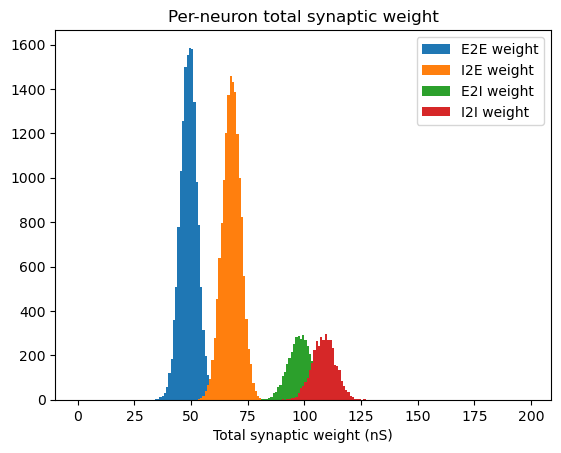

Sum of weights to average neuron:
E2E: 48.952762761271046 (nS)
E2I: 98.01205429079255 (nS)
I2E: 67.83888979693369 (nS)
I2I: 108.6232378135341 (nS)

IE ratio (Exc.): 1.3858030879230456
IE ratio (Inh.): 1.1082640660837408

Expected IE ratio (Exc.): 1.416666666666667
Expected IE ratio (Inh.): 1.1333333333333333


Array([0.00094   , 0.00112144, 0.00116628, ..., 0.00114602, 0.00094801,
       0.00117626], dtype=float32)

In [9]:
# * Calculate the per-neuron EI balance
# DONT USE REQUIRES, SINCE THAT REBUILDS THE ARRAY
# ? How to peroperly check the balance of weights?
I2E = bp.connect.csr2coo((FNSnet.I2E.proj.comm.indices, FNSnet.I2E.proj.comm.indptr))
E2E = bp.connect.csr2coo((FNSnet.E2E.proj.comm.indices, FNSnet.E2E.proj.comm.indptr))
E2I = bp.connect.csr2coo((FNSnet.E2I.proj.comm.indices, FNSnet.E2I.proj.comm.indptr))
I2I = bp.connect.csr2coo((FNSnet.I2I.proj.comm.indices, FNSnet.I2I.proj.comm.indptr))
w_I2E = FNSnet.I2E.proj.comm.weight
w_E2E = FNSnet.E2E.proj.comm.weight
w_E2I = FNSnet.E2I.proj.comm.weight
w_I2I = FNSnet.I2I.proj.comm.weight
assert len(I2E[0]) == len(w_I2E)

Ne = np.prod(FNSnet.E.size)
Ni = np.prod(FNSnet.I.size)
bin_w_E2E = np.bincount(E2E[1], weights=w_E2E, minlength=Ne)
bin_w_I2E = np.bincount(I2E[1], weights=w_I2E, minlength=Ne)
bin_w_E2I = np.bincount(E2I[1], weights=w_E2I, minlength=Ni)
bin_w_I2I = np.bincount(I2I[1], weights=w_I2I, minlength=Ni)
bins = np.arange(0, 200, 1)
plt.hist(bin_w_E2E*1000, bins=bins, label="E2E weight")
plt.hist(bin_w_I2E*1000, bins=bins, label="I2E weight")
plt.hist(bin_w_E2I*1000, bins=bins, label="E2I weight")
plt.hist(bin_w_I2I*1000, bins=bins, label="I2I weight")
plt.legend()
plt.title("Per-neuron total synaptic weight")
plt.xlabel("Total synaptic weight (nS)")
plt.show()

# plt.scatter(bin_w_E2E, bin_w_I2E)
# plt.show()

# plt.hist(bin_w_E2E/bin_w_I2E, bins=50)
# plt.show()

# * Print sum of weights in table
print("Sum of weights to average neuron:")
print("E2E:", np.mean(bin_w_E2E)*1000, "(nS)") # Should be approx 2100
print("E2I:", np.mean(bin_w_E2I)*1000, "(nS)") # approx 3800
print("I2E:", np.mean(bin_w_I2E)*1000, "(nS)") # 5800
print("I2I:", np.mean(bin_w_I2I)*1000, "(nS)") # 8100

# * Calculate an IE ratio for each population defined as the ratio of average total incoming
#   inhibitory synaptic strength to average total incoming excitatory synaptic strength for
#   a specific neuron type
print("")
IE_e, IE_i = FNSnet.calculate_zeta()
print("IE ratio (Exc.):", IE_e)
print("IE ratio (Inh.):", IE_i)

print("")
IE_e_hat, IE_i_hat = FNSnet.expected_zeta()
print("Expected IE ratio (Exc.):", IE_e_hat)
print("Expected IE ratio (Inh.):", IE_i_hat)
w_E2E

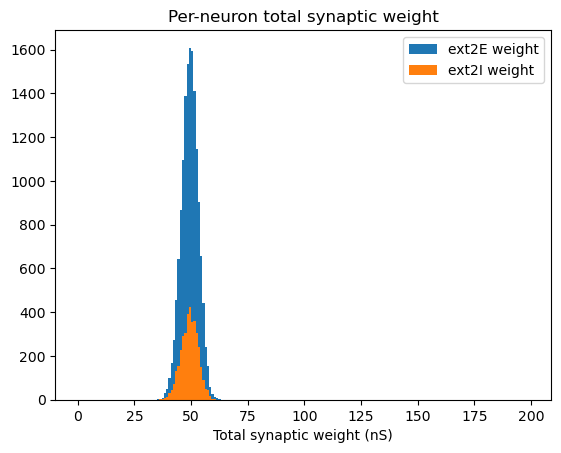

Sum of weights to average neuron (from external):
ext2E: 49.451588129022184 (nS)
ext2I: 49.3355271880549 (nS)


In [10]:
# * As previous cell, but for external pop
ext2E = bp.connect.csr2coo((FNSnet.ext2E.proj.comm.indices, FNSnet.ext2E.proj.comm.indptr))
ext2I = bp.connect.csr2coo((FNSnet.ext2I.proj.comm.indices, FNSnet.ext2I.proj.comm.indptr))
w_ext2E = FNSnet.ext2E.proj.comm.weight
w_ext2I = FNSnet.ext2I.proj.comm.weight
assert len(ext2E[0]) == len(w_ext2E)

bin_w_ext2E = np.bincount(ext2E[1], weights=w_ext2E, minlength=Ne)
bin_w_ext2I = np.bincount(ext2I[1], weights=w_ext2I, minlength=Ni)
plt.hist(bin_w_ext2E*1000, bins=bins, label="ext2E weight")
plt.hist(bin_w_ext2I*1000, bins=bins, label="ext2I weight")
plt.legend()
plt.title("Per-neuron total synaptic weight")
plt.xlabel("Total synaptic weight (nS)")
plt.show()

# plt.scatter(bin_w_ext2E, bin_w_ext2I)
# plt.show()

# plt.hist(bin_w_ext2E/bin_w_ext2I, bins=50)
# plt.show()

print("Sum of weights to average neuron (from external):")
print("ext2E:", np.mean(bin_w_ext2E)*1000, "(nS)") # Should be approx 1000
print("ext2I:", np.mean(bin_w_ext2I)*1000, "(nS)") # approx 1000


In [11]:
# * No per-neuron balance
# ! xx No common-neighbour property
# ! xx No reverse pooling or lognormal coupling weights
bp.reset_state(FNSnet)
# * Simulate
# I = np.array(FNSnet.E.V.value)
# I[:] = 0.0
# i = I.reshape(*FNSnet.E.size)
# i[0:25, 0:25] = 0.0

runner = bp.DSRunner(FNSnet, monitors=['E.V', 'I.V', 'E.spike', 'I.spike', 'E.g_K', 'I.g_K','E.input', 'I.input'])# , inputs = [('Ein.input', I)])
runner.run(duration=4000.)

# t = runner.mon['ts'].view()
# X = runner.mon['E.spike'].view()

Predict 40000 steps: : 100%|██████████| 40000/40000 [00:08<00:00, 4631.58it/s]


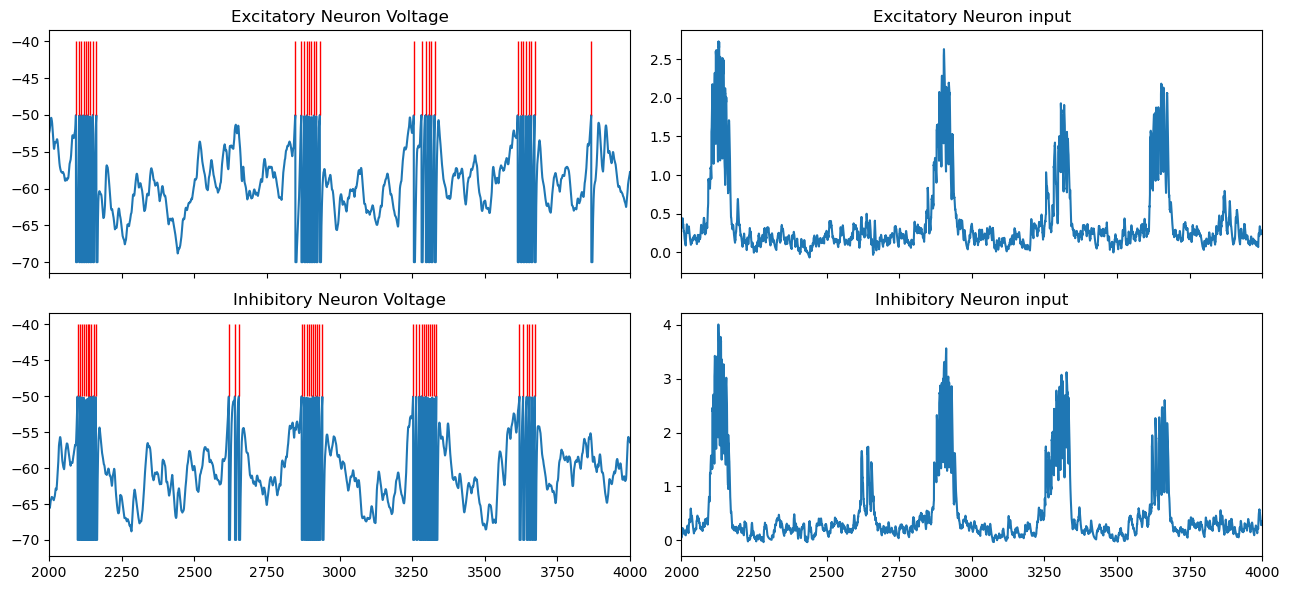

In [12]:
idx_e = 10

# * Pick the inhibitory neuron closest to idx_e
e_pos = np.array(FNSnet.E.positions[idx_e])
i_pos = FNSnet.I.positions
dists = np.linalg.norm(i_pos - e_pos, axis=1)
idx_i = np.argmin(dists)

fig, axs = plt.subplots(2, 2, figsize=(13, 6), sharex=True)
x = runner.mon['E.V'].view()[:, idx_e]
spikes = np.where(runner.mon['E.spike'].view()[:, idx_e])
axs[0, 0].plot(runner.mon['ts'].view(), x)
spike_times = runner.mon['ts'][spikes]
axs[0, 0].vlines(spike_times, FNSnet.E.V_th, FNSnet.E.V_th + 10,
                  color='r', linewidth=1)
axs[0, 0].set_title('Excitatory Neuron Voltage')

x = runner.mon['I.V'].view()[:, idx_i]
spikes = np.where(runner.mon['I.spike'].view()[:, idx_i])
axs[1, 0].plot(runner.mon['ts'].view(), x)
spike_times = runner.mon['ts'][spikes]
axs[1, 0].vlines(spike_times, FNSnet.I.V_th, FNSnet.I.V_th + 10,
                  color='r', linewidth=1)
axs[1, 0].set_title('Inhibitory Neuron Voltage')

x = runner.mon['E.input'].view()[:, idx_e]
axs[0, 1].plot(runner.mon['ts'].view(), x)
axs[0, 1].set_title('Excitatory Neuron input')

x = runner.mon['I.input'].view()[:, idx_i]
axs[1, 1].plot(runner.mon['ts'].view(), x)
axs[1, 1].set_title('Inhibitory Neuron input')

plt.xlim(2000, 4000)
plt.tight_layout()
plt.show()

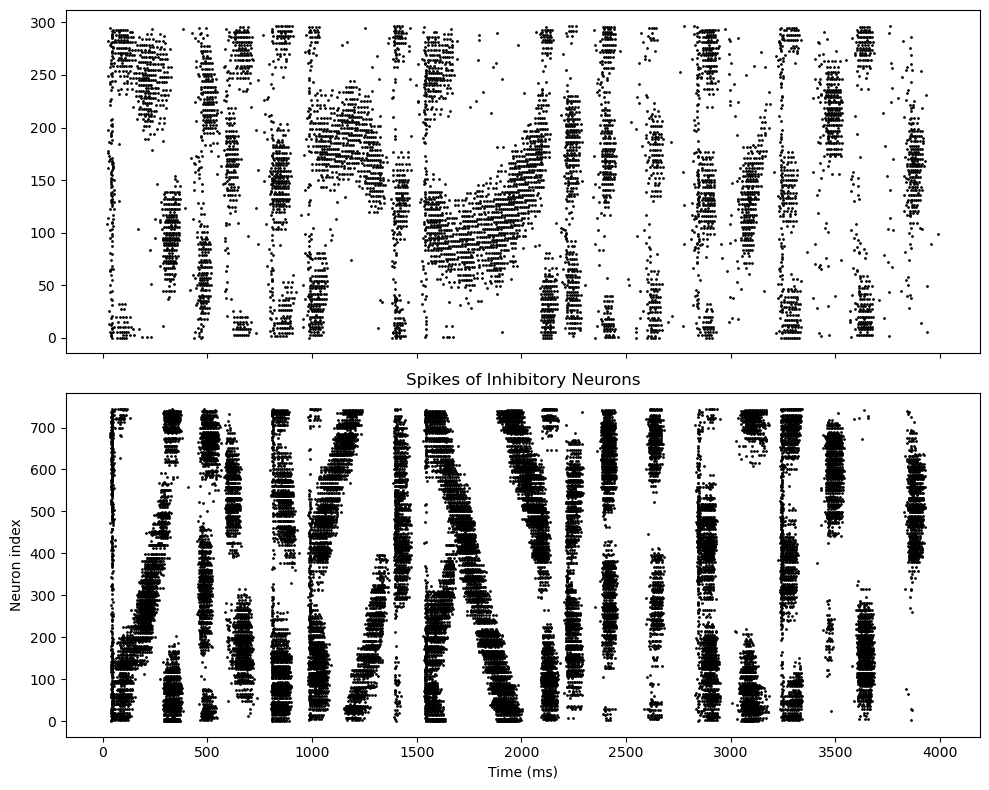

In [13]:
# Create a figure and two subplots (stacked vertically)
fig, axs = plt.subplots(2, 1, figsize=(10, 8), sharex=True)

# Plot the raster for excitatory neurons on the first subplot.
bp.visualize.raster_plot(runner.mon["ts"], runner.mon["E.spike"][:, ::50],
                           title="Spikes of Excitatory Neurons", ax=axs[0])
# Plot the raster for inhibitory neurons on the second subplot.
bp.visualize.raster_plot(runner.mon["ts"], runner.mon["I.spike"][:, ::5],
                           title="Spikes of Inhibitory Neurons", ax=axs[1])

plt.tight_layout()
plt.show()

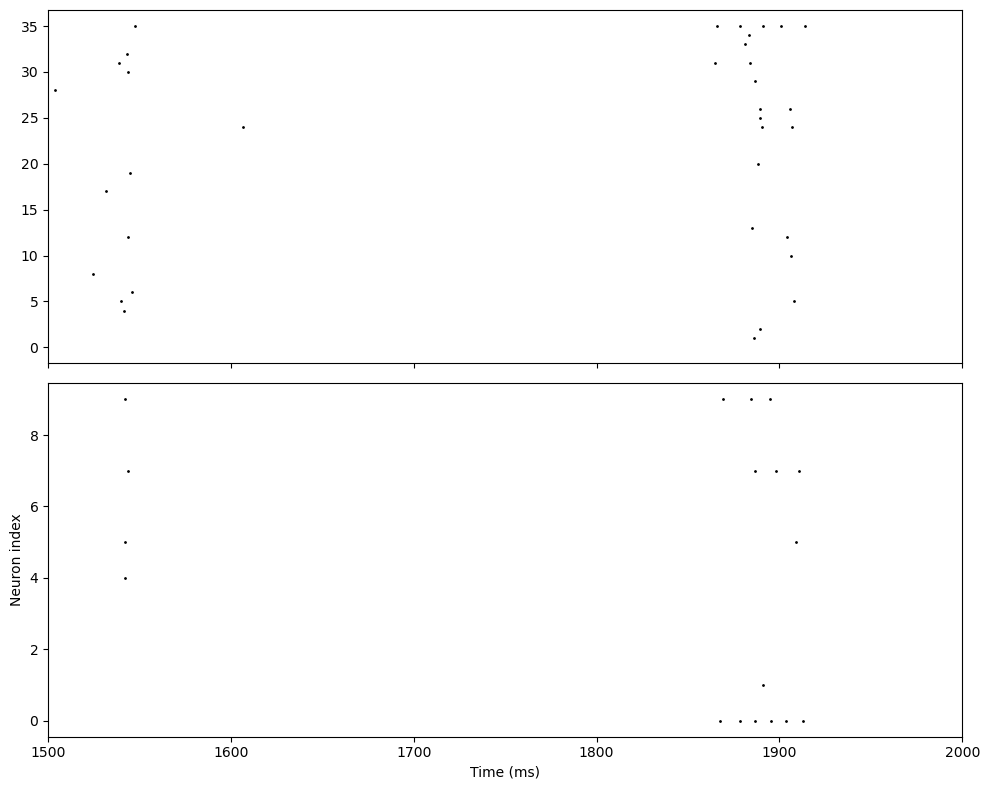

In [14]:
# Define patch parameters
patchwidth = 0.05  # width of the patch (adjust as needed)
# Define the lower-left corner of the patch (adjust as needed)
patch_x = 0.1
patch_y = 0.1

# Retrieve spatial positions of excitatory and inhibitory neurons.
# Here we assume that runner.E.embedding and runner.I.embedding exist and are (N, 2) arrays.
E_pos = np.array(FNSnet.E.positions)  # shape: (num_E_neurons, 2)
I_pos = np.array(FNSnet.I.positions)  # shape: (num_I_neurons, 2)

# Create Boolean masks for neurons within the patch
mask_E = (E_pos[:, 0] >= patch_x) & (E_pos[:, 0] <= patch_x + patchwidth) & \
         (E_pos[:, 1] >= patch_y) & (E_pos[:, 1] <= patch_y + patchwidth)

mask_I = (I_pos[:, 0] >= patch_x) & (I_pos[:, 0] <= patch_x + patchwidth) & \
         (I_pos[:, 1] >= patch_y) & (I_pos[:, 1] <= patch_y + patchwidth)

# Filter the spike raster for neurons within the patch.
# Assume that runner.mon["E.spike"] and runner.mon["I.spike"] are 2D arrays of shape (time, neurons)
E_spikes_patch = runner.mon["E.spike"][:, mask_E]
I_spikes_patch = runner.mon["I.spike"][:, mask_I]

# Create a figure with two subplots (stacked vertically)
fig, axs = plt.subplots(2, 1, figsize=(10, 8), sharex=True)

# Plot the raster for excitatory neurons within the patch
bp.visualize.raster_plot(runner.mon["ts"], E_spikes_patch, ax=axs[0])

# Plot the raster for inhibitory neurons within the patch
bp.visualize.raster_plot(runner.mon["ts"], I_spikes_patch, ax=axs[1])

axs[0].set_xlim(1500, 2000)
axs[1].set_xlim(1500, 2000)
plt.tight_layout()
plt.show()

In [15]:
# # * First, plot the current distribution of synaptic weights
# ws = FNSnet.E2E.proj.comm.weight
# plt.hist(ws, bins=50)
# plt.gca().set_title('E2E weights')

# # * And the number of synapses per neuron
# plt.figure()
# plt.hist(np.diff(FNSnet.E2E.proj.comm.indptr), bins=50) # ! Check !!!
# plt.gca().set_title('Number of synapses per neuron')
# plt.show()

In [16]:
# bp.visualize.raster_plot(t, X, title='Spikes of Excitatory Neurons', show=True)
%matplotlib inline
from src.plots import animate_spiking_activity
from IPython.display import HTML
ani = animate_spiking_activity(FNSnet, runner, ms_per_s=100, fps=24, window_size_ms=5, tstart=0)

ani.save("spiking_activity.mp4", writer="ffmpeg")
# HTML(ani.to_jshtml())

In [17]:
# import copy

# # * Try parallell simulation
# FNSnet.reinit_weights(85)
# FNSnet.reinit_nu(130)
# bp.reset_state(FNSnet) # Resets all things recursively, unlike FNSnet.reset_state()

# def model_array(model, Js, nus):
#     models = []
#     for J, nu in zip(Js, nus):
#         m = copy.deepcopy(model)
#         m.reinit_weights(J)
#         m.reinit_nu(nu)
#         models.append(m)
#     return models

# def run_model(model):
#     bp.reset_state(model) # Resets all things recursively, unlike FNSnet.reset_state()
#     runner = bp.DSRunner(FNSnet, monitors=['E.spike'])# , inputs = [('Ein.input', I)])
#     runner.run(duration=5000.)
#     return runner


# js = np.linspace(80, 90, 2)
# nus = np.full(js.shape, 130)
# all_params = zip(js, nus)
# bp.running.cpu_ordered_parallel(run_model, all_params, num_process=10)

In [18]:
# @jax.jit
# def test():
#     FNSnet.reinit_nu(85)
#     return FNSnet.

# test()

In [19]:
# @jax.jit
# def test_build():
#     other = WRCircuit(rho = rho, dx=dx, J_e = J_e,
#         nu = 2.5, n_ext = 25, delta=4,
#         p_ee=p_ee,
#         p_ei=p_ei,
#         p_ie=p_ie,
#         p_ii=p_ii,
#         sigma_ee=sigma_ee,
#         sigma_ei=sigma_ei,
#         sigma_ie=sigma_ie,
#         sigma_ii=sigma_ii,
#         kernel=kernel,
#         key=jax.random.PRNGKey(42),
#         copy_conn=FNSnet) # Copy connectivity from the original circuit to avoid slow rebuilding
#     return other

# test_build()

In [20]:
# other = WRCircuit(rho = rho, dx=dx, J_e = J_e,
#         nu = 2.5, n_ext = 25, delta=4,
#         p_ee=p_ee,
#         p_ei=p_ei,
#         p_ie=p_ie,
#         p_ii=p_ii,
#         sigma_ee=sigma_ee,
#         sigma_ei=sigma_ei,
#         sigma_ie=sigma_ie,
#         sigma_ii=sigma_ii,
#         kernel=kernel,
#         key=jax.random.PRNGKey(42),
#         copy_conn=FNSnet) # COpy connectivity from the original circuit to avoid slow rebuilding
# other.reinit_nu(123)
# print(other.ext.freqs)
# print(FNSnet.ext.freqs) # SHould not match :)

In [21]:
# params = {"rho" : rho, "dx":dx, "J_e" : J_e,
#         "nu" : 2.5, "n_ext" : 25, "delta":4,
#         "p_ee":p_ee,
#         "p_ei":p_ei,
#         "p_ie":p_ie,
#         "p_ii":p_ii,
#         "sigma_ee":sigma_ee,
#         "sigma_ei":sigma_ei,
#         "sigma_ie":sigma_ie,
#         "sigma_ii":sigma_ii,
#         "kernel":kernel,
#         "key":jax.random.PRNGKey(42)}
# def copy_run(delta, nu, model, duration=1000., monitors=['E.spike']):
#     new_model = model.update_copy(delta=delta, nu=nu)
#     runner = bp.DSRunner(model, monitors=monitors)
#     runner.run(duration=duration)
#     return runner

# nus = np.linspace(120, 140, 2)
# deltas = np.linspace(80, 90, 2)
# # models = [copy_model(j, 130, FNSnet, params) for j in js]
# bp.running.cpu_unordered_parallel(copy_run, [deltas, nus, [FNSnet]], num_process=10)


In [22]:
FNSnet.key

Array([4279588804, 3759507778], dtype=uint32)

In [23]:
# def run(model, duration=1000., monitors=['E.spike']):
#     runner = bp.DSRunner(model, monitors=monitors)
#     runner.run(duration=duration)
#     return runner


In [24]:
# FNSnet

In [25]:
# # * Need to be able to batch run small models
# # * How can we have a pure function that takes model parameters, reconstructs a new model,
# #   then runs it?
# def sweep_nu(model, monitors=['E.spike']):
#     conn = model.get_connectivity()
#     def run(nu):
#         print(nu)
#         new_model = model.copy()
#         new_model.reinit_nu(nu)
#         bp.reset_state(new_model)
#         runner = bp.DSRunner(new_model, monitors=monitors, numpy_mon_after_run=False)
#         runner.run(duration=1000.)
#         return [runner.mon[m] for m in monitors]
#     return run
# # res = jax.vmap(copy_run(FNSnet))(np.array(range(1, 3)))
# res = bp.running.jax_vectorize_map(sweep_nu(FNSnet), [np.array(range(10, 12))], num_parallel=2, clear_buffer=False)
# res

In [26]:
# def sweep_delta(model, duration=1000., monitors=['E.spike']):
#     conn = model.get_connectivity()
#     def run(delta):
#         new_model = model.copy()
#         new_model.reinit_weights(delta)
#         bp.reset_state(new_model)
#         runner = bp.DSRunner(new_model, monitors=monitors, numpy_mon_after_run=False)
#         runner.run(duration=duration)
#         return [runner.mon[m] for m in monitors]
#     return run
# run = sweep_delta(FNSnet, duration=1000., monitors=['E.spike'])
# res = bp.running.jax_vectorize_map(run, [np.array(range(10, 12))], num_parallel=2, clear_buffer=False)
# res

In [27]:
# res = FNSnet.sweep_deltas(np.array(range(1, 10)), duration=1000., monitors=['E.spike'], num_parallel=1)

In [28]:
os.cpu_count()
jax.devices('cpu')

[CpuDevice(id=0)]